# Desafio

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import string
import nltk
import numpy as np
from sklearn import tree
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.cluster import DBSCAN
from sklearn.model_selection import cross_val_score

nltk.download('stopwords')
nltk.download('vader_lexicon')

[nltk_data] Downloading package stopwords to /Users/pedro/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/pedro/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

## Funções para limpar o texto das reviews

In [123]:
PONTUACAO = string.punctuation

def remove_pontuacao(text):
    return text.translate(str.maketrans('', '', PONTUACAO))

STOPWORDS = set(stopwords.words('english'))

def remove_stopwords(text):
    return " ".join([word for word in str(text).split() if word not in STOPWORDS])

sent = SentimentIntensityAnalyzer()

In [124]:
df_biz_train = pd.read_csv("data/X_trainToronto.csv")
df_reviews_train = pd.read_csv("data/reviewsTrainToronto.csv")

df_biz_test = pd.read_csv("data/X_testToronto.csv")
df_reviews_test = pd.read_csv("data/reviewsTestToronto.csv")

## Funções para preparar os dados de treino e teste
* Altera o tipo da coluna is_open para bool
* Transforma a coluna categories em uma lista
* Utiliza o algoritmo DBSCAN para clusterizar os estabelecimentos utilizando latitude e longitude
* Realiza pré-processamento nos textos das reviews e calcula a polaridade do sentimento do texto

In [125]:
def prepare_biz(df_biz: pd.DataFrame) -> pd.DataFrame:
    df_biz["is_open"] = df_biz["is_open"].astype(bool)
    df_biz['category_list'] = df_biz['categories'].fillna('').apply(lambda x: [c.strip() for c in x.split(',')])
    df_lat = df_biz[["latitude", "longitude"]]
    kms_por_radian = 6371.0088
    dbscan_config = DBSCAN(eps=0.5 /kms_por_radian, min_samples=10, metric="haversine")
    dbscan_results = dbscan_config.fit(np.radians(df_lat))
    df_biz["cluster"] = dbscan_results.labels_

    return df_biz

def prepare_reviews(df_reviews: pd.DataFrame) -> pd.DataFrame:
    df_reviews["text"] = df_reviews["text"].str.lower()
    df_reviews["text"] = df_reviews["text"].apply(remove_pontuacao)
    df_reviews["text"] = df_reviews["text"].apply(remove_stopwords)

    df_reviews["compound"] = df_reviews["text"].apply(lambda text: sent.polarity_scores(text)["compound"])
    return df_reviews

In [126]:
df_biz_train = prepare_biz(df_biz_train)
df_reviews_train = prepare_reviews(df_reviews_train)
df_biz_test = prepare_biz(df_biz_test)
df_reviews_test = prepare_reviews(df_reviews_test)

## Agrega dados de reviews ao dataframe para estabelecimentos

In [127]:
def merge_agg_dfs(df_biz: pd.DataFrame, df_reviews: pd.DataFrame) -> pd.DataFrame:
    reviews_business_agg = df_reviews.groupby('business_id').agg( avg_compound=("compound", "mean")).reset_index()
    df = pd.merge(df_biz, reviews_business_agg)
    return df
df_train = merge_agg_dfs(df_biz_train, df_reviews_train)
df_test = merge_agg_dfs(df_biz_test, df_reviews_test)

In [128]:
df_train.head(1)

,business_id,name,address,postal_code,latitude,longitude,review_count,is_open,attributes,categories,hours,loc,destaque,category_list,cluster,avg_compound
0,vHzWmPWHN4J1hRR3W3AMQg,Salt Wine Bar,225 Ossington Ave,M6J 2Z8,43.648977,-79.420495,99,True,"{'Ambience': ""{'romantic': False, 'intimate': False, 'classy': False, 'hipster': False, 'divey': False, 'touristy': False, 'trendy': True, 'upscale': False, 'casual': False}"", 'Caters': 'False', 'WiFi': ""u'no'"", 'OutdoorSeating': 'False', 'GoodForMeal': ""{'dessert': False, 'latenight': False, 'lunch': False, 'dinner': True, 'brunch': False, 'breakfast': False}"", 'RestaurantsTakeOut': 'False', 'RestaurantsAttire': ""u'casual'"", 'NoiseLevel': ""u'average'"", 'RestaurantsDelivery': 'False', 'RestaurantsPriceRange2': '3', 'GoodForKids': 'False', 'RestaurantsGoodForGroups': 'True', 'Alcohol': ""u'full_bar'"", 'BusinessParking': ""{'garage': False, 'street': True, 'validated': False, 'lot': False, 'valet': False}"", 'BikeParking': 'True', 'HasTV': 'False', 'RestaurantsReservations': 'True'}","Wine Bars, Tapas/Small Plates, Restaurants, Bars, Nightlife","{'Monday': '18:0-23:0', 'Tuesday': '18:0-23:0', 'Wednesday': '18:0-23:0', 'Thursday': '18:0-23:0', 'Friday': '18:0-1:0', 'Saturday': '17:30-22:30'}","{'type': 'Point', 'coordinates': [-79.4204946, 43.648977]}",0,"[Wine Bars, Tapas/Small Plates, Restaurants, Bars, Nightlife]",0,0.880899


## Utiliza o algoritmo Apriori para encontrar regras de associação nas categorias

In [129]:
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
from mlxtend.preprocessing import TransactionEncoder
te = TransactionEncoder()
encoded = te.fit(df_train["category_list"]).transform(df_train["category_list"])
df_train_apriori = pd.DataFrame(encoded, columns=te.columns_)
df_train_apriori["destaque"] = df_train["destaque"].astype(bool)

In [130]:
frequent_itemsets = apriori(df_train_apriori, min_support=0.001, use_colnames=True)
frequent_itemsets

,support,itemsets
0,0.001536,()
1,0.015357,(Accessories)
2,0.039529,(Active Life)
3,0.007963,(Acupuncture)
4,0.001138,(Adult Entertainment)
...,...,...
4621,0.001024,"(Bikes, Sporting Goods, destaque, Shopping, Bike Repair/Maintenance, Local Services)"
4622,0.001763,"(Mags, destaque, Music & Video, Books, Shopping, Bookstores)"
4623,0.001422,"(Mags, Music & Video, Music & DVDs, Vinyl Records, Books, Shopping)"
4624,0.001251,"(Bars, Restaurants, Beer, Nightlife, Wine & Spirits, Food, Canadian (New))"


## List as 10 regras com mais confiança

In [131]:
df_regras = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.25)
mask = df_regras['consequents'].apply(lambda cons: 'destaque' in cons)
df_regras[mask].sort_values(by="confidence", ascending=False).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
4649,"(Home Services, Real Estate Agents)",(destaque),0.002161,0.193266,0.001479,0.684211,3.540256,1.0,0.001061,2.554658,0.719089,0.007625,0.608558,0.345931
10903,"(Real Estate, Home Services, Real Estate Agents)",(destaque),0.002161,0.193266,0.001479,0.684211,3.540256,1.0,0.001061,2.554658,0.719089,0.007625,0.608558,0.345931
5180,(Real Estate Agents),"(destaque, Real Estate)",0.002161,0.002616,0.001479,0.684211,261.517162,1.0,0.001473,3.158382,0.998334,0.448276,0.683382,0.624714
10910,(Real Estate Agents),"(Home Services, destaque, Real Estate)",0.002161,0.002616,0.001479,0.684211,261.517162,1.0,0.001473,3.158382,0.998334,0.448276,0.683382,0.624714
10908,"(Real Estate, Real Estate Agents)","(Home Services, destaque)",0.002161,0.007508,0.001479,0.684211,91.134769,1.0,0.001463,3.142892,0.991169,0.180556,0.681822,0.440590
10906,"(Home Services, Real Estate Agents)","(destaque, Real Estate)",0.002161,0.002616,0.001479,0.684211,261.517162,1.0,0.001473,3.158382,0.998334,0.448276,0.683382,0.624714
939,(Real Estate Agents),(destaque),0.002161,0.193266,0.001479,0.684211,3.540256,1.0,0.001061,2.554658,0.719089,0.007625,0.608558,0.345931
5178,"(Real Estate, Real Estate Agents)",(destaque),0.002161,0.193266,0.001479,0.684211,3.540256,1.0,0.001061,2.554658,0.719089,0.007625,0.608558,0.345931
4651,(Real Estate Agents),"(Home Services, destaque)",0.002161,0.007508,0.001479,0.684211,91.134769,1.0,0.001463,3.142892,0.991169,0.180556,0.681822,0.440590
13577,"(Physical Therapy, Beauty & Spas, Massage Therapy)","(Health & Medical, destaque)",0.001934,0.020703,0.001251,0.647059,31.254363,1.0,0.001211,2.774675,0.969880,0.058511,0.639597,0.353749


## Cria uma nova coluna indicando se o estabelecimento tem uma das categorias associadas com destaque
As categorias foram selecionadas manualmente com base na lista das 10 regras com mais confiança

In [132]:
check_set = {"Home Services", 'Real Estate', 'Real Estate Agents'}
df_train['destaque_category'] = df_train['category_list'].apply(lambda cats: any(cat in check_set for cat in cats))
df_test['destaque_category'] = df_test['category_list'].apply(lambda cats: any(cat in check_set for cat in cats))

## Transforma colunas contínuas em categóricas

In [133]:
def categorize_polarity(value):
    if value < 0.5:
        return 'Low'
    elif value < 0.7:
        return 'Medium'
    elif value < 0.8:
        return 'High'
    else:
        return 'Very High'

def categorize_reviews_count(value):
    if value < 5:
        return 'Low'
    elif value < 10:
        return 'Medium'
    elif value < 25:
        return 'High'
    else:
        return 'Very High'

df_train['reviews_cat'] = df_train['avg_compound'].apply(categorize_polarity)
df_test['reviews_cat'] = df_test['avg_compound'].apply(categorize_polarity)
df_train['reviews_count_cat'] = df_train['review_count'].apply(categorize_reviews_count)
df_test['reviews_count_cat'] = df_test['review_count'].apply(categorize_reviews_count)


## Seleciona as colunas que serão utilizadas para treinamento e predição e transforma categorias em valores "dummy" com a técnica one-hot-encoding

In [134]:
use_cols = ["cluster", "reviews_count_cat", "reviews_cat", "is_open", "destaque_category"]
X_train = df_train[use_cols]
X_test = df_test[use_cols]
y_train = df_train["destaque"]
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

## Utiliza um grid search para encontrar os melhores parâmetros para a árvore de decisão, utilizando validação 10-fold e a métrica f1

In [135]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7, 10, 15, 20],
    'min_samples_leaf': [1, 5, 10, 20, 50, 100]
}

grid_tree = tree.DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(grid_tree, param_grid, cv=10, scoring='f1_macro')
grid_search.fit(X_train, y_train)

print("Best parameters: ", grid_search.best_params_)
print("Best cross-validation score: ", grid_search.best_score_)

Best parameters:  {'max_depth': 3, 'min_samples_leaf': 1}
Best cross-validation score:  0.7050169405938443


In [136]:
tree_model = tree.DecisionTreeClassifier(max_depth = 3, min_samples_leaf = 1)
tree_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Mostra a árvore de decisão

[]

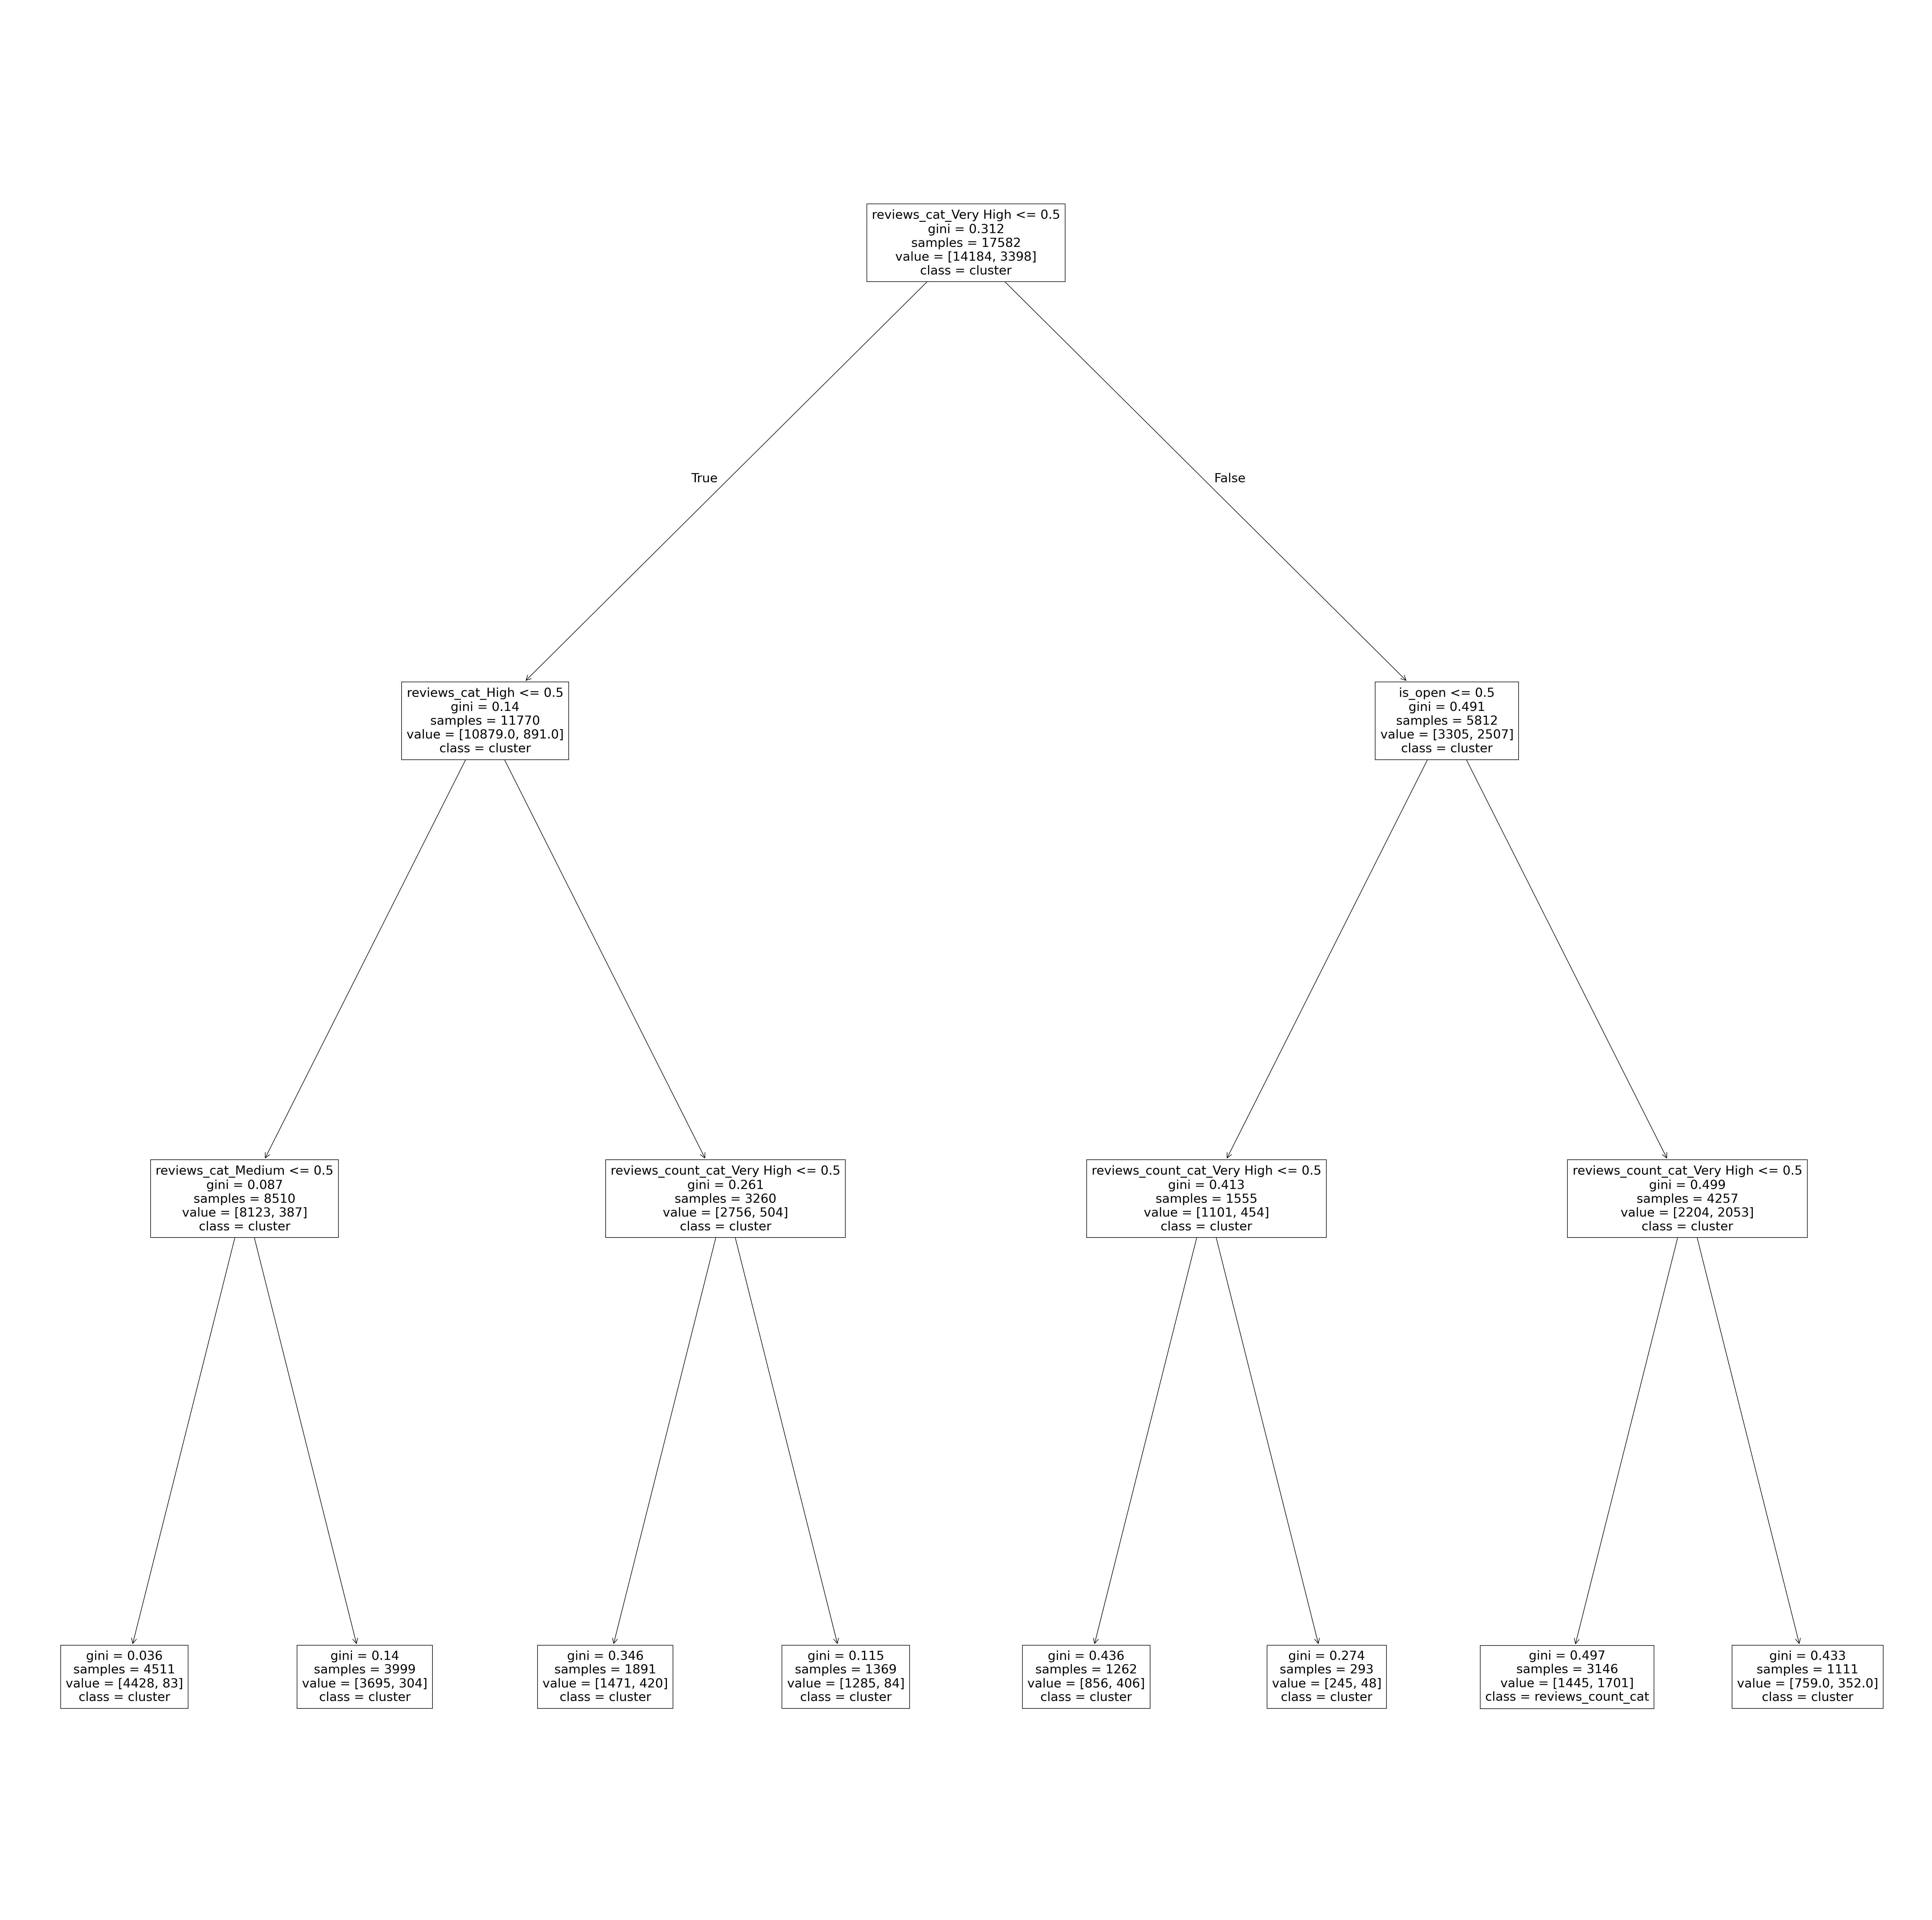

In [137]:
fig, axes = plt.subplots(figsize = (60,60), dpi=150)
tree.plot_tree(tree_model, feature_names = X_train.columns, class_names=use_cols)
plt.plot()

## Utiliza o modelo de predição e salva um arquivo com os resultados

In [138]:
df_test["destaque"] = tree_model.predict(X_test)
results = df_test[["business_id", "destaque"]].set_index("business_id")
results["destaque"] = results["destaque"].astype(int)
results.to_csv(f"data/tree-8.csv")

## Resultados e discussão
A nota dos resultados obtidos utilizando uma árvore de decisão varia entre 0.53 e 0.55. Este resultado é melhor do que o obtido utilizando uma classificação aleatória, porém, ainda existem muitas oportunidades de melhoria, principalmente no pré-processamento da base de dados.

Os atributos dos estabelecimentos não foram utilizados pela complexidade no processamento e sua utilização pode influenciar positivamente nos resultados obtidos.

A escolha das categorias relacionadas a estabelecimentos com notas altas teve como base os resultados do algoritmo de associação Apriori, porém, foi completamente intuitiva.

Os parâmetros utilizados para a clusterização com base na latitude e longitude precisam ser otimizados. Os clusters encontrados tem uma influência praticamente nula no resultado final.